# Singapore Public Sector Hospital Admissions  

## Load and reshape the data

The source file is wide: one row per hospital/series and one column per month.  
For analysis, we reshape it into a long format with one row per month so that time trends and comparisons become easier to read.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["font.size"] = 10

raw = pd.read_csv(r"C:\Users\owner\Downloads\AdmissionsToPublicSectorHospitalsMonthly.csv")

# Clean series names
raw["DataSeries"] = raw["DataSeries"].str.strip()

# Wide -> long
df = raw.set_index("DataSeries").T.reset_index().rename(columns={"index": "Date"})
df["Date"] = pd.to_datetime(df["Date"], format="%Y%b")

# Convert all numeric columns
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Date").reset_index(drop=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

total_col = "Public Sector Hospital Admissions"
hospital_cols = [c for c in df.columns if c not in ["Date", "Year", "Month", total_col]]

acute_hospitals = [
    "Alexandra Hospital",
    "Changi General Hospital",
    "Khoo Teck Puat Hospital",
    "National University Hospital",
    "Ng Teng Fong General Hospital",
    "Sengkang General Hospital",
    "Singapore General Hospital",
    "Woodlands Health Campus",
    "Tan Tock Seng Hospital",
    "Kandang Kerbau Women's & Children's Hospital",
]

df.head()


DataSeries,Date,Public Sector Hospital Admissions,Alexandra Hospital,Changi General Hospital,Khoo Teck Puat Hospital,National University Hospital,Ng Teng Fong General Hospital,Sengkang General Hospital,Singapore General Hospital,Woodlands Health Campus,Tan Tock Seng Hospital,Communicable Disease Centre,National Centre For Infectious Diseases,Institute Of Mental Health / Woodbridge Hospital,Kandang Kerbau Women's & Children's Hospital,National Heart Centre,Year,Month
0,1987-01-01,18822,2345.0,NaN,NaN,1864,NaN,NaN,5224,NaN,3937,NaN,NaN,493,2412,NaN,1987,1
1,1987-02-01,19074,2188.0,NaN,NaN,1862,NaN,NaN,5490,NaN,4061,NaN,NaN,480,2420,NaN,1987,2
2,1987-03-01,22173,2641.0,NaN,NaN,2584,NaN,NaN,6447,NaN,4128,NaN,NaN,518,2892,NaN,1987,3
3,1987-04-01,19797,2348.0,NaN,NaN,2202,NaN,NaN,5761,NaN,3804,NaN,NaN,498,2686,NaN,1987,4
4,1987-05-01,19602,2357.0,NaN,NaN,2032,NaN,NaN,5754,NaN,3629,NaN,NaN,469,2739,NaN,1987,5


In [3]:
# Quick data overview
summary = pd.DataFrame(
    {
        "Metric": [
            "Date range",
            "Monthly observations",
            "Total series in file",
            "Hospital columns",
            "First month total admissions",
            "Latest month total admissions",
            "Growth since first month",
            "2025 annual total admissions",
        ],
        "Value": [
            f"{df['Date'].min():%b %Y} to {df['Date'].max():%b %Y}",
            f"{len(df):,}",
            f"{len(raw):,}",
            f"{len(hospital_cols):,}",
            f"{int(df.iloc[0][total_col]):,}",
            f"{int(df.iloc[-1][total_col]):,}",
            f"{(df.iloc[-1][total_col] / df.iloc[0][total_col] - 1) * 100:.1f}%",
            f"{int(df.loc[df['Year'] == 2025, total_col].sum()):,}",
        ],
    }
)

display(summary)


,Metric,Value
0,Date range,Jan 1987 to Feb 2026
1,Monthly observations,470
2,Total series in file,15
3,Hospital columns,14
4,First month total admissions,"18,822"
5,Latest month total admissions,"42,797"
6,Growth since first month,127.4%
7,2025 annual total admissions,"559,671"


## What does the long-run trend look like?

- This chart shows the monthly total admissions series with a 12-month moving average.  
- The grey bands mark SARS and COVID-19 disruption windows. 

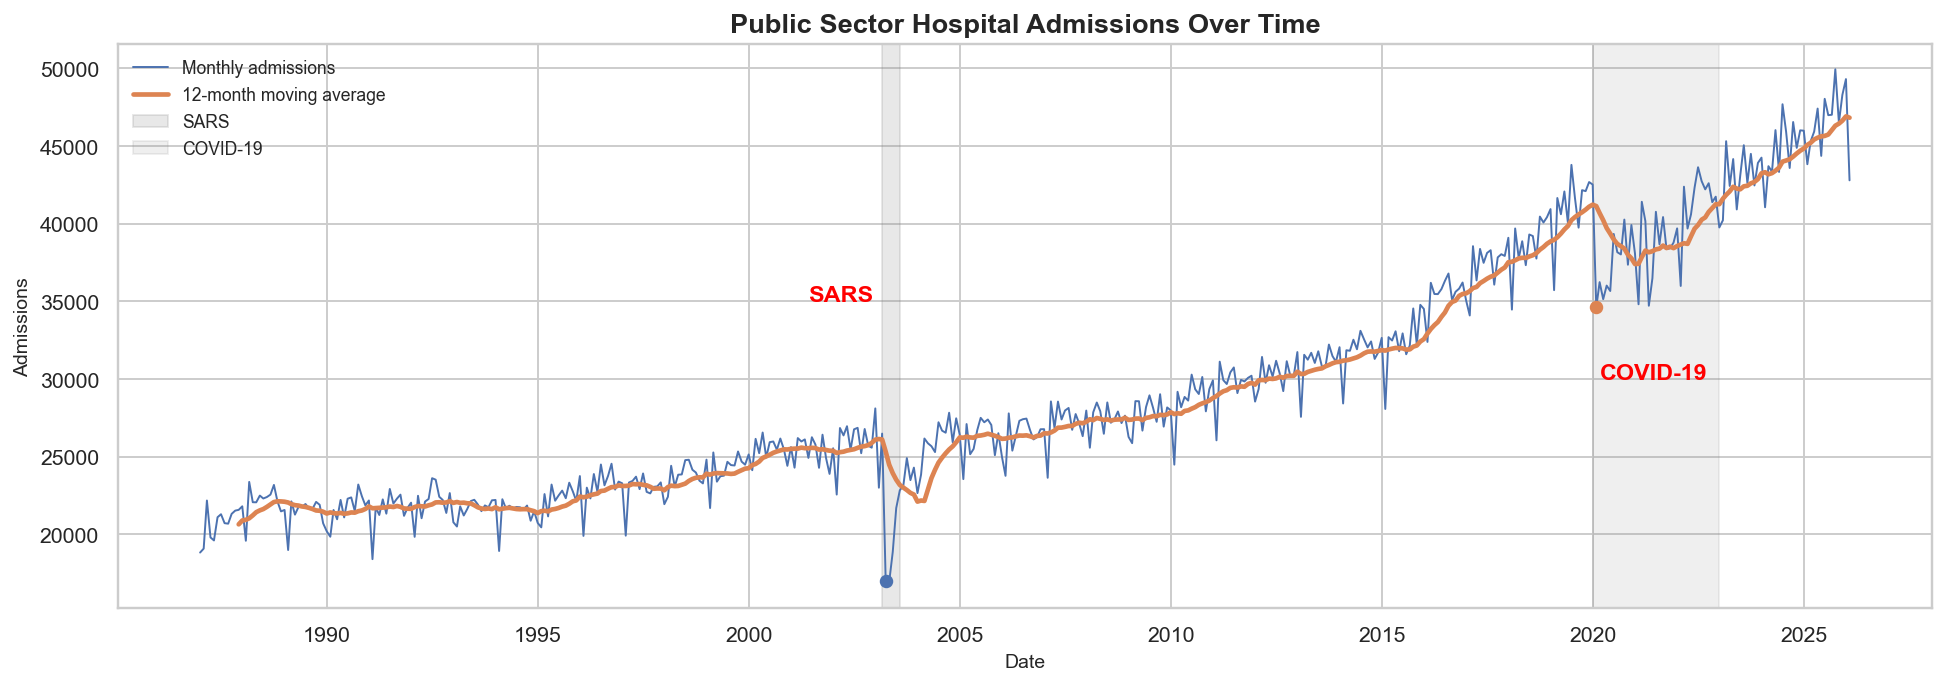

In [4]:

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["Date"], df[total_col], linewidth=1, label="Monthly admissions")
ax.plot(df["Date"], df[total_col].rolling(12).mean(), linewidth=2.4, label="12-month moving average")

# Grey bands highlight major outbreak periods (approximate monthly windows)
ax.axvspan(pd.Timestamp("2003-03-01"), pd.Timestamp("2003-08-01"), color="grey", alpha=0.18, label="SARS")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2022-12-31"), color="grey", alpha=0.12, label="COVID-19")

# Highlight the biggest month-on-month drops in the series
mom = df[total_col].pct_change()
drop_dates = df.loc[mom.nsmallest(3).index, "Date"].tolist()
drop_vals = df.loc[mom.nsmallest(3).index, total_col].tolist()

for d, v in zip(drop_dates[:2], drop_vals[:2]):
    ax.scatter(d, v, s=35, zorder=3)

ax.set_title("Public Sector Hospital Admissions Over Time")
ax.set_ylabel("Admissions")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.text(pd.Timestamp("2001-06-01"), 35000, 'SARS', color='red', fontsize=12, fontweight='bold')
ax.text(pd.Timestamp("2020-03-01"), 30000, 'COVID-19', color='red', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

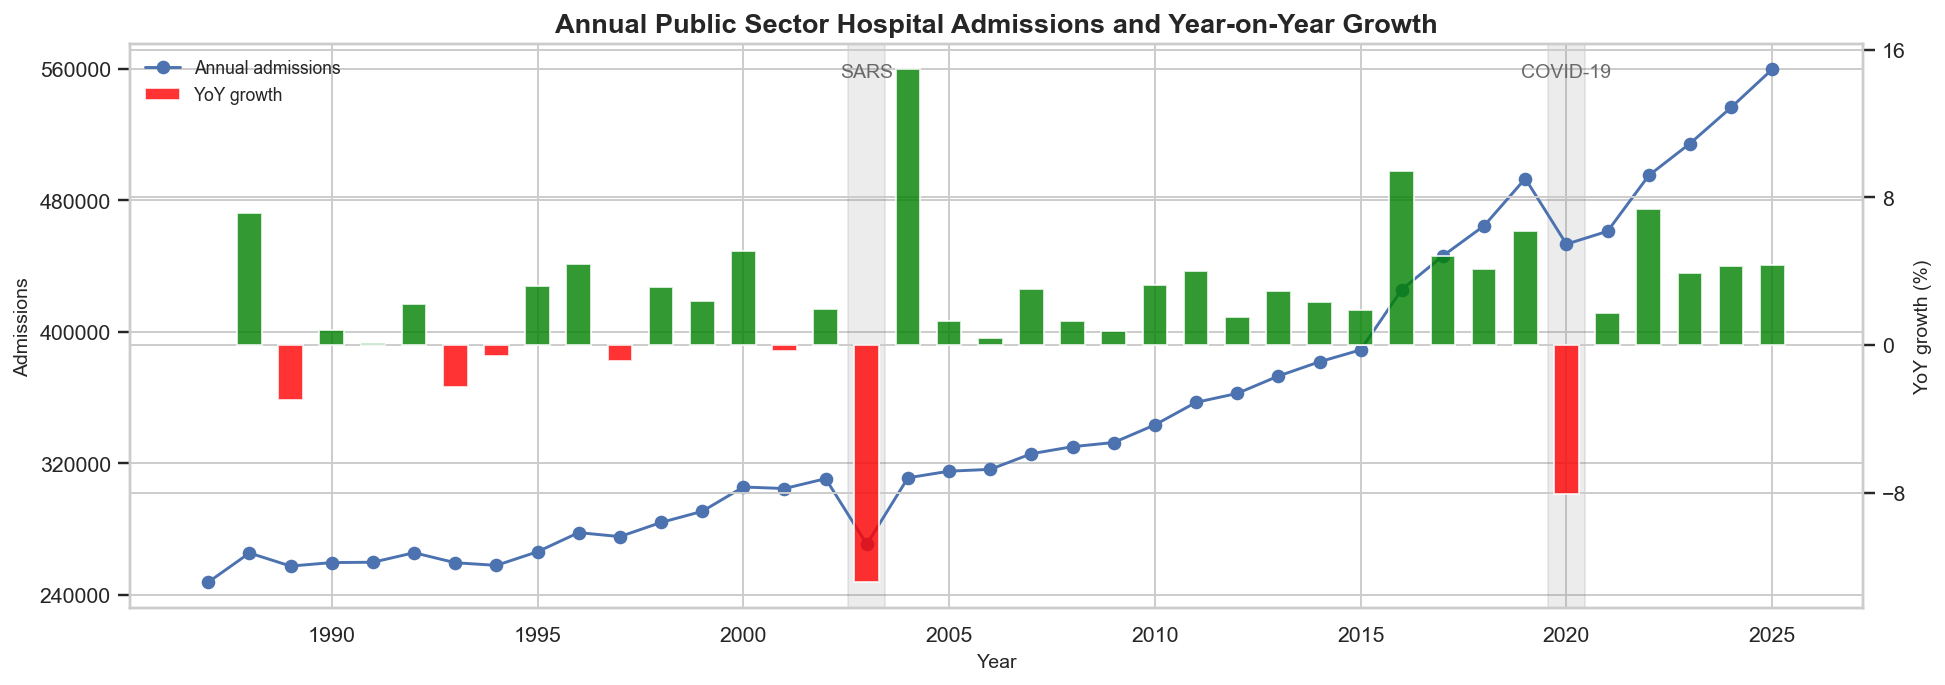

In [7]:
latest_complete_year = df["Year"].max() if df["Date"].max().month == 12 else df["Year"].max() - 1
annual = df.loc[df["Year"] <= latest_complete_year].groupby("Year")[total_col].sum()
annual_yoy = annual.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(annual.index, annual.values, marker="o", label="Annual admissions")
ax1.set_title("Annual Public Sector Hospital Admissions and Year-on-Year Growth")
ax1.set_xlabel("Year")
ax1.set_ylabel("Admissions")

# Lightly mark the major outbreak years for context
for year, label in [(2003, "SARS"), (2020, "COVID-19")]:
    if year in annual.index:
        ax1.axvspan(year - 0.45, year + 0.45, color="grey", alpha=0.15)
        ax1.text(year, ax1.get_ylim()[1] * 0.98, label, ha="center", va="top", fontsize=10, color="dimgray")

color = ['green' if v >= 0 else 'red' for v in annual_yoy.values]
ax2 = ax1.twinx()
ax2.bar(annual_yoy.index, annual_yoy.values, alpha=0.8, width=0.6, label="YoY growth", color=color)
ax2.set_ylabel("YoY growth (%)")

# Build a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")


# Align gridlines between dual axes
from matplotlib.ticker import MaxNLocator
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None))

plt.tight_layout()
plt.show()

### Key takeaways
- Admissions rise over the long run, which suggests steady pressure on the public hospital system. This is strongly tied to Singapore's demographic shift. The resident population aged 65+ doubled from 7% in 1999 to 15.2% in 2020, and is projected to reach 32% by 2060. The trend is structural and is projected to continue in the long run.


- The series is still volatile month to month, so a moving average smooths out the data to help visualise overall trends. This could help with planning and communication.
- Sharp dips in admissions during SARS and COVID-19, likely due to suspension of non-emergency services and avoidance of hospitals.

## Is there a seasonal pattern by month?

- The next view looks at the average month-of-year pattern and the spread of values for each month.  
- Seasonality matters because hospital demand is rarely random. It is often influenced by holidays, viral seasons, and how care is scheduled across the year.

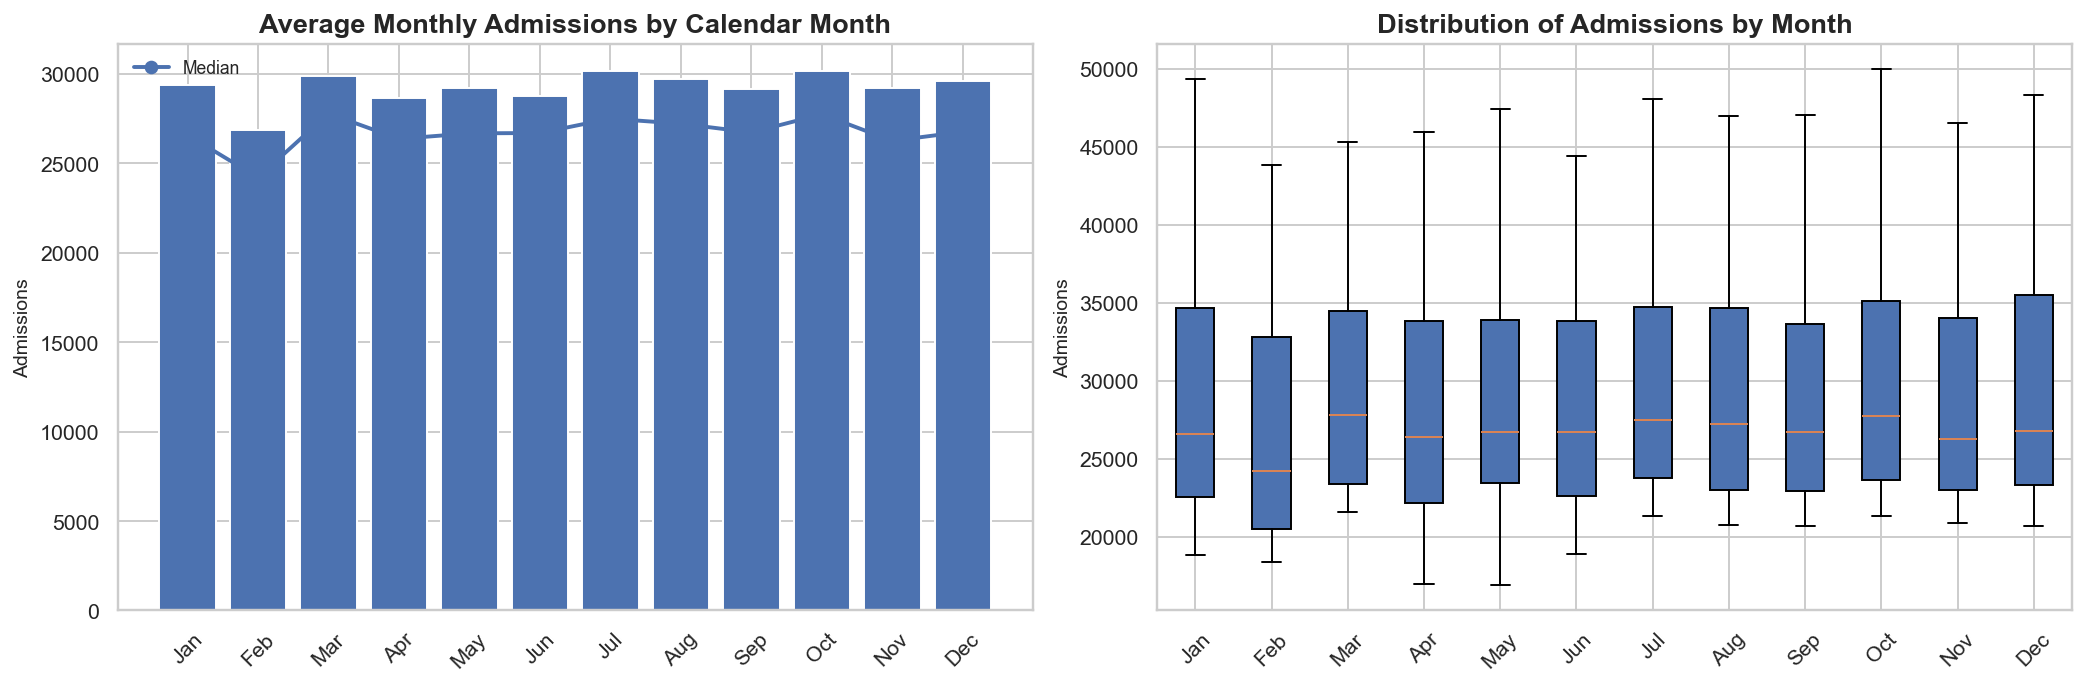

In [5]:
month_order = list(range(1, 13))
month_names = pd.to_datetime(pd.Series(month_order), format="%m").dt.strftime("%b").tolist()
month_avg = df.groupby("Month")[total_col].mean().reindex(month_order)
month_median = df.groupby("Month")[total_col].median().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: average by month
axes[0].bar(month_names, month_avg.values)
axes[0].plot(month_names, month_median.values, marker="o", linewidth=2, label="Median")
axes[0].set_title("Average Monthly Admissions by Calendar Month")
axes[0].set_ylabel("Admissions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Right: distribution by month
month_data = [df.loc[df["Month"] == m, total_col].dropna().values for m in month_order]
axes[1].boxplot(month_data, tick_labels=month_names, patch_artist=True)
axes[1].set_title("Distribution of Admissions by Month")
axes[1].set_ylabel("Admissions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
month_table = (
    pd.DataFrame({
        "Month": month_names,
        "Average admissions": month_avg.values,
        "Median admissions": month_median.values,
    })
    .sort_values("Average admissions", ascending=False)
    .reset_index(drop=True)
)

display(month_table)

lowest = month_table.iloc[-1]
highest = month_table.iloc[0]
print(f"Lowest average month: {lowest['Month']} ({lowest['Average admissions']:.0f})")
print(f"Highest average month: {highest['Month']} ({highest['Average admissions']:.0f})")
print(f"Gap: {highest['Average admissions'] - lowest['Average admissions']:.0f} admissions")


,Month,Average admissions,Median admissions
0,Jul,30180.230769,27499.0
1,Oct,30180.025641,27743.0
2,Mar,29900.025641,27785.0
3,Aug,29685.923077,27214.0
4,Dec,29604.923077,26763.0
5,Jan,29391.500000,26585.0
6,May,29216.615385,26675.0
7,Nov,29186.435897,26255.0
8,Sep,29162.820513,26727.0
9,Jun,28782.128205,26695.0


Lowest average month: Feb (26842)
Highest average month: Jul (30180)
Gap: 3339 admissions


### Key takeaways
February consistently marks the annual low point for hospital discharges, a phenomenon driven by two primary factors. Chronologically, February is the shortest month of the year, and with 2 to 3 fewer days than its neighbors, it naturally records a lower total volume of activity. Furthermore, the dip is further amplified by the cultural significance of Chinese New Year (CNY). In Singapore, there is a widespread preference for patients to be home for the holidays, perhaps leading to a flurry of pre-emptive discharges in late January and a deliberate reduction in elective admissions during the festive period itself. This avoidance of the hospital environment during CNY results in lower admissions in February. The boxplot reinforces this, with February's interquartile range sitting noticeably lower than every other month.

## Which hospitals carry the load today?

 To keep things simple, I focus on the acute hospitals that are most relevant for general inpatient demand.

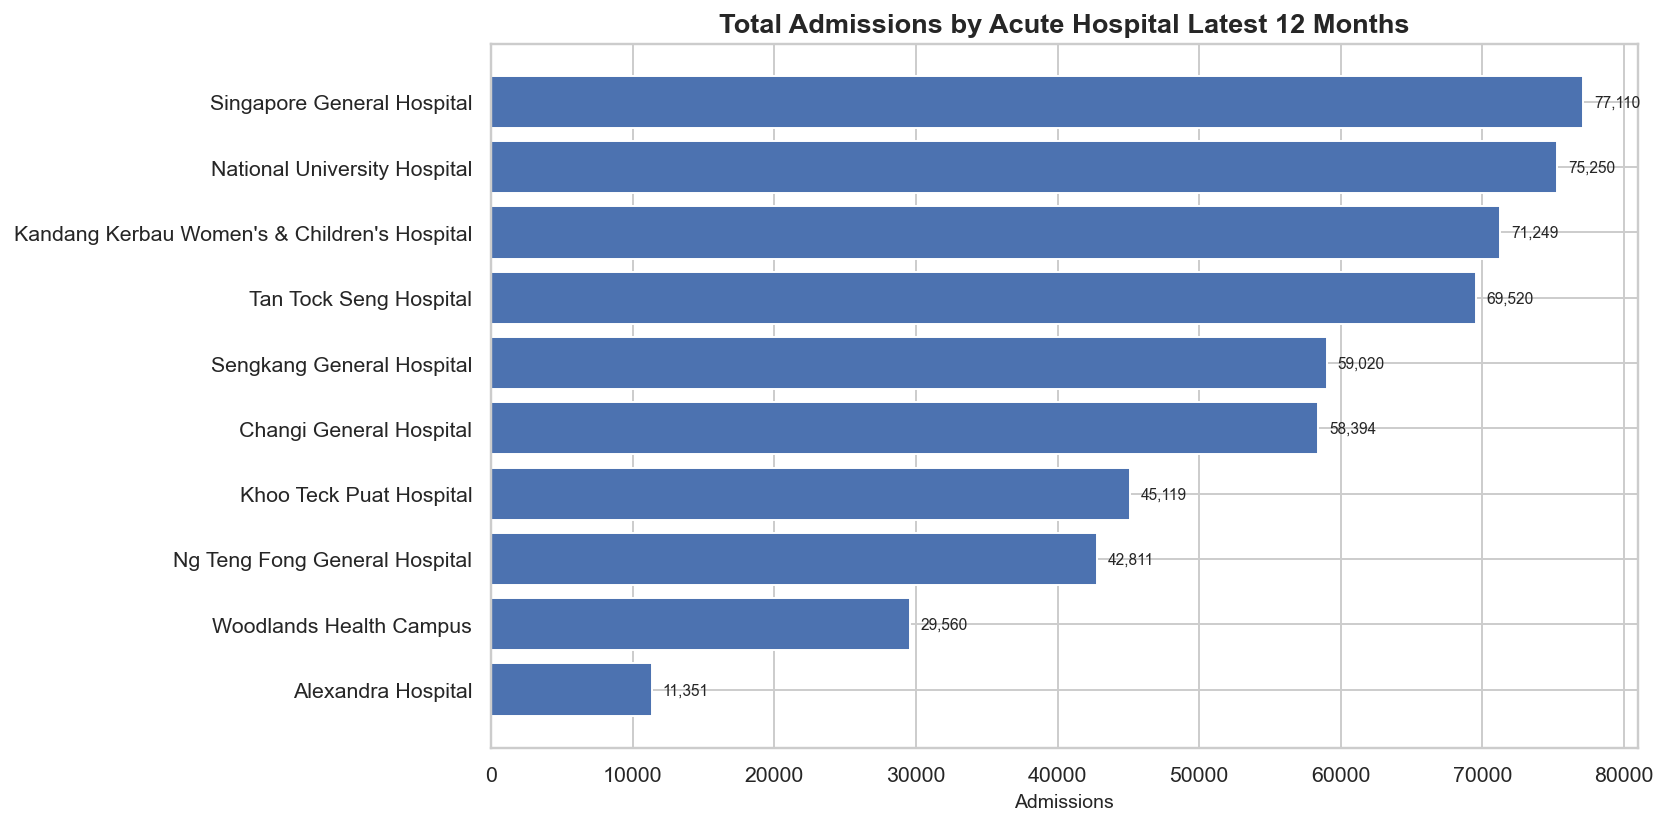

Top-4 acute hospitals account for 54.3% of acute-hospital admissions in the latest 12 months.


In [12]:

latest12 = df.tail(12)
acute_latest = latest12[acute_hospitals].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(acute_latest.index, acute_latest.values)
ax.set_title("Total Admissions by Acute Hospital Latest 12 Months")
ax.set_xlabel("Admissions")
ax.set_ylabel("")

# Add labels to make the concentration easier to read
for bar in bars:
    width = bar.get_width()
    ax.text(width + acute_latest.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{int(width):,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

top4_share = acute_latest.sort_values(ascending=False).head(4).sum() / acute_latest.sum() * 100
print(f"Top-4 acute hospitals account for {top4_share:.1f}% of acute-hospital admissions in the latest 12 months.")


In [9]:

# A compact table showing when each hospital first appears in the file
first_valid = []
for col in acute_hospitals:
    idx = df[col].first_valid_index()
    first_valid.append(
        {
            "Hospital": col,
            "First month in series": df.loc[idx, "Date"] if idx is not None else pd.NaT,
            "Latest month in series": df.loc[df[col].last_valid_index(), "Date"] if df[col].last_valid_index() is not None else pd.NaT,
        }
    )

first_valid_table = pd.DataFrame(first_valid).sort_values("First month in series")
display(first_valid_table)


,Hospital,First month in series,Latest month in series
0,Alexandra Hospital,1987-01-01,2026-02-01
3,National University Hospital,1987-01-01,2026-02-01
6,Singapore General Hospital,1987-01-01,2026-02-01
8,Tan Tock Seng Hospital,1987-01-01,2026-02-01
9,Kandang Kerbau Women's & Children's Hospital,1987-01-01,2026-02-01
1,Changi General Hospital,1997-01-01,2026-02-01
2,Khoo Teck Puat Hospital,2010-06-01,2026-02-01
4,Ng Teng Fong General Hospital,2015-07-01,2026-02-01
5,Sengkang General Hospital,2018-07-01,2026-02-01
7,Woodlands Health Campus,2024-05-01,2026-02-01


### What this means
- A small number of large hospitals still carry most of the acute inpatient load.
- Newer hospitals enter the series later and help absorb growth, which is a reminder that infrastructure expansion is one lever, but network design is another.
- For planning, this points to the importance of load balancing, referral coordination, and making sure manpower is not overly concentrated in a few facilities.


## Do hospital demand move together?

A correlation heatmap is a simple way to see whether hospitals rise and fall together.
For readability, I use a smaller set of major acute hospitals.


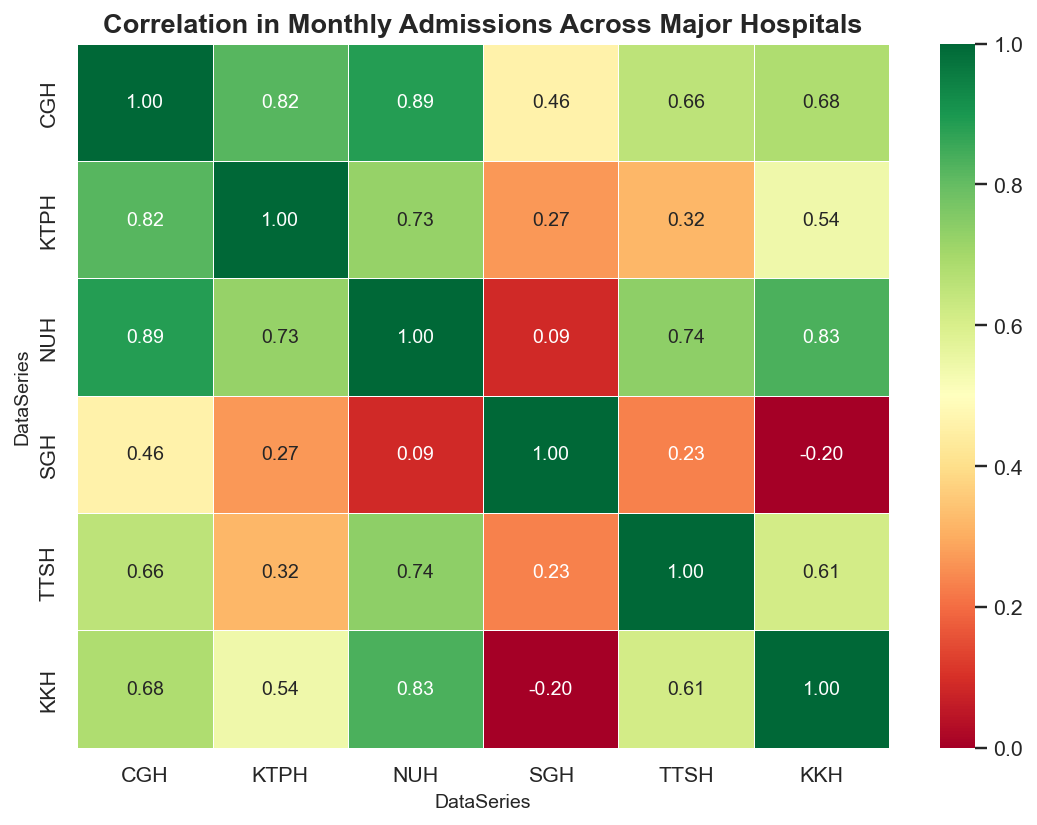

In [10]:

corr_hospitals = [
    "Changi General Hospital",
    "Khoo Teck Puat Hospital",
    "National University Hospital",
    "Singapore General Hospital",
    "Tan Tock Seng Hospital",
    "Kandang Kerbau Women's & Children's Hospital",
]

abbr = {
    "Changi General Hospital": "CGH",
    "Khoo Teck Puat Hospital": "KTPH",
    "National University Hospital": "NUH",
    "Singapore General Hospital": "SGH",
    "Tan Tock Seng Hospital": "TTSH",
    "Kandang Kerbau Women's & Children's Hospital": "KKH",
}

corr = df[corr_hospitals].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    xticklabels=[abbr[c] for c in corr_hospitals],
    yticklabels=[abbr[c] for c in corr_hospitals],
)
ax.set_title("Correlation in Monthly Admissions Across Major Hospitals")
plt.tight_layout()
plt.show()


### Interpretation
- High correlations suggest that some hospitals face similar demand cycles.


- That matters for planning because several hospitals may peak at the same time, so strain can spread across the network rather than staying isolated.
- A practical takeaway is that extra capacity cannot always be shifted easily between highly correlated hospitals during a surge.
